# Packages

In [93]:
%matplotlib widget

In [94]:
try:
    import cupy as xp
except ImportError:
    import numpy as xp

In [95]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from scipy.ndimage import shift
from skimage.transform import warp
from scipy.ndimage import sobel, gaussian_filter

In [96]:
from libertem_holo.base.io import Results
from libertem_holo.base.align import ImageCorrelator
from libertem_holo.base.fine_adjust import fine_adjust
from libertem_holo.base.filters import clipped
from libertem_holo.base.unwrap import phase_unwrap, quality_unwrap, derivative_variance

# Load hologram stacks

Data is loaded directly as a Results object from a previous reconstruction notebook. The dataset contains the complex wave, the unwrapped phase, the brightfield image as well as some metadata information (like pixel size).

In [111]:
#data_minus = Results.load("/storage/er-c-data/adhoc/libertem/libertem-test-data/dm/holo/align/minus.npz")
#data_plus = Results.load("/storage/er-c-data/adhoc/libertem/libertem-test-data/dm/holo/align/plus.npz")
data_minus = Results.load("/storage/er-c-data/adhoc/mnp_holo/minus2.npz")
data_plus = Results.load("/storage/er-c-data/adhoc/mnp_holo/plus2.npz")


In this example notebook, two holograms were acquired on the same Fe3O4 nanoparticle after excitation from the objective lens in two different magnetic field: +1 T (`data_plus`) and -1 T (`data_minus`). The magnetization is reversed between both datasets, allowing the substraction of Mean Inner Potential (MIP). The alignment of both phase images will be described using 2 differents methods: phase cross correlation and manual alignment using an interactive GUI.

Text(0.5, 1.0, 'Plus')

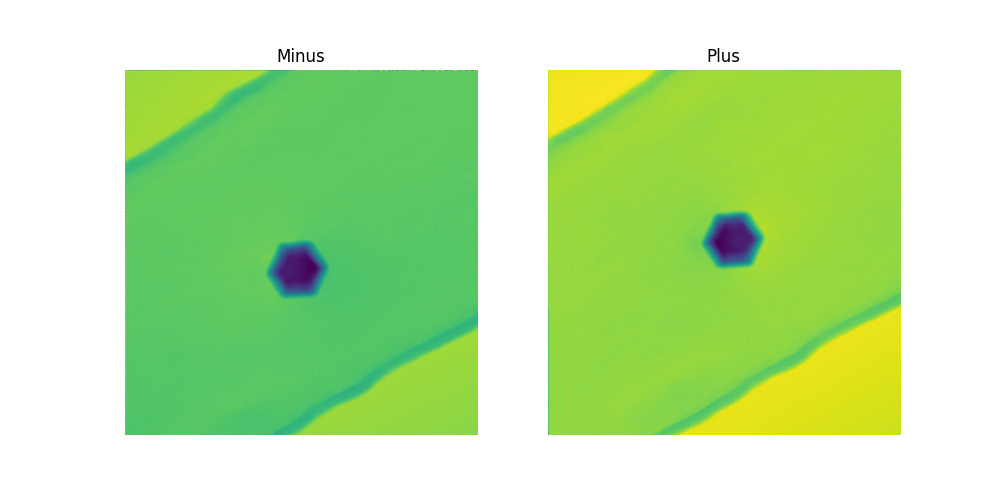

In [112]:
fig, ax = plt.subplots(ncols=2, figsize=(10,5))
ax[0].imshow(data_minus.unwrapped_phase)
ax[0].axis('off')
ax[0].set_title('Minus')
ax[1].imshow(data_plus.unwrapped_phase)
ax[1].axis('off')
ax[1].set_title('Plus')

The phase or the brightfield can be used for alignment. The advantage of the brightfield image is to not possess any artefacts from magnetization or electrostatic potential difference between datasets.

In [ ]:
phase_minus = data_minus.unwrapped_phase
phase_plus = data_plus.unwrapped_phase

In [ ]:
bf_minus = data_minus.brightfield
bf_plus = data_plus.brightfield

# Cross correlation

The cross correlation class can be used with different types of parameters, but the outline remains the same:
1. Initialize the Correlator object
2. Prepare the inputs
3. Correlate the inputs
4. Shift the moving input based on the maximum of the correlation map

In [113]:
correlator = ImageCorrelator(hanning=True, binning=2, upsample_factor=10, normalization='phase', xp=np)

In [114]:
roi = np.s_[100:-100, 100:-100]

In [118]:
ref_image = correlator.prepare_input(bf_minus[roi])
moving_image = correlator.prepare_input(bf_plus[roi])

In [119]:
corr_results = correlator.correlate(ref_image, moving_image)

The correlation map can be plotted to check the spread of the maximum, or potential artefacts from the FFTs.

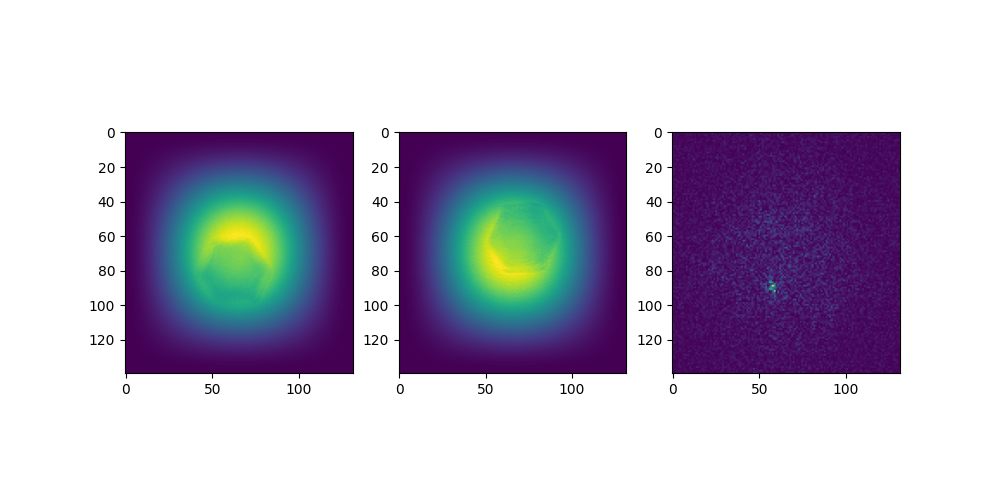

In [120]:
fig, ax = plt.subplots(ncols=3, figsize=(10,5))
ax[0].imshow(np.abs(ref_image))
ax[1].imshow(np.abs(moving_image))
ax[2].imshow(corr_results.corrmap)

In [121]:
corr_results.shift

(np.float64(38.599999999999994), np.float64(-17.200000000000003))

In [122]:
phase_plus_shifted = shift(phase_plus, corr_results.shift)

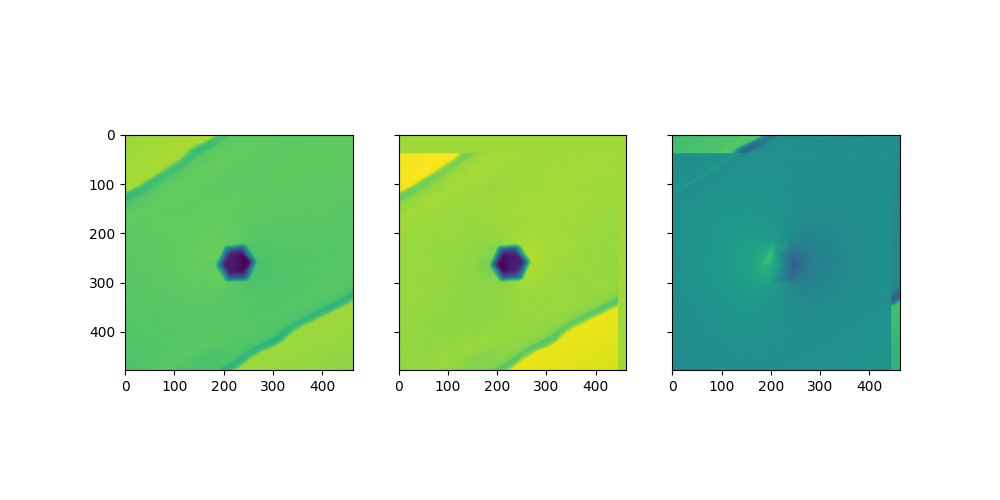

In [ ]:
fig, ax = plt.subplots(ncols=3, figsize=(10, 5), sharex=True, sharey=True)
ax[0].imshow(phase_minus)
ax[1].imshow(phase_plus_shifted)
ax[2].imshow(phase_minus - phase_plus_shifted)

MIP and magnetic phase can now be calculated.

In [124]:
MIP_phase = (phase_minus + phase_plus_shifted) / 2
MAG_phase = (phase_minus - phase_plus_shifted) / 2

For induction field lines visualisation, a cosine can be applied to the magnetic phase.

Text(0.5, 1.0, 'cos(MAG*16)')

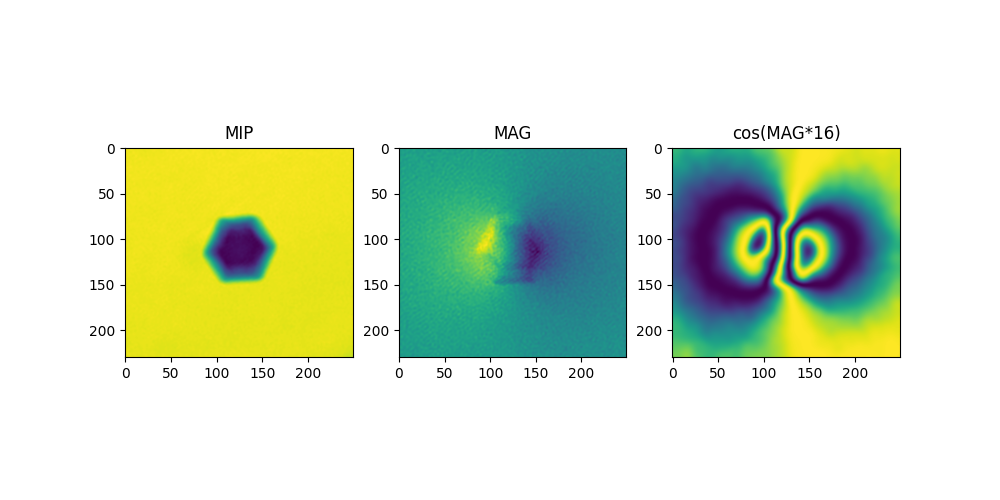

In [129]:
fig, ax = plt.subplots(ncols=3, figsize=(10, 5))
roi = np.s_[150:380, 100:350]
ax[0].imshow(MIP_phase[roi])
ax[0].set_title('MIP')

ax[1].imshow(MAG_phase[roi])
ax[1].set_title('MAG')

ax[2].imshow(np.cos(gaussian_filter(MAG_phase[roi], sigma=5)*16))
ax[2].set_title('cos(MAG*16)')

# Manual alignment

If the cross correlation is not working (data too noisy) or if there is both translation and rotation transformation, a manual alignment can be necessary.

In [130]:
fig, getter = fine_adjust(phase_minus, phase_plus)
fig

BokehModel(combine_events=True, render_bundle={'docs_json': {'74bc7f85-36f0-4f27-ab7d-d4675a5fb04d': {'version…

In [133]:
transf_matrix = getter()
phase_plus_shifted = warp(phase_plus, transf_matrix)

transf_matrix = AffineTransform(matrix=
    [[  1.,   0.,  17.],
     [  0.,   1., -39.],
     [  0.,   0.,   1.]]

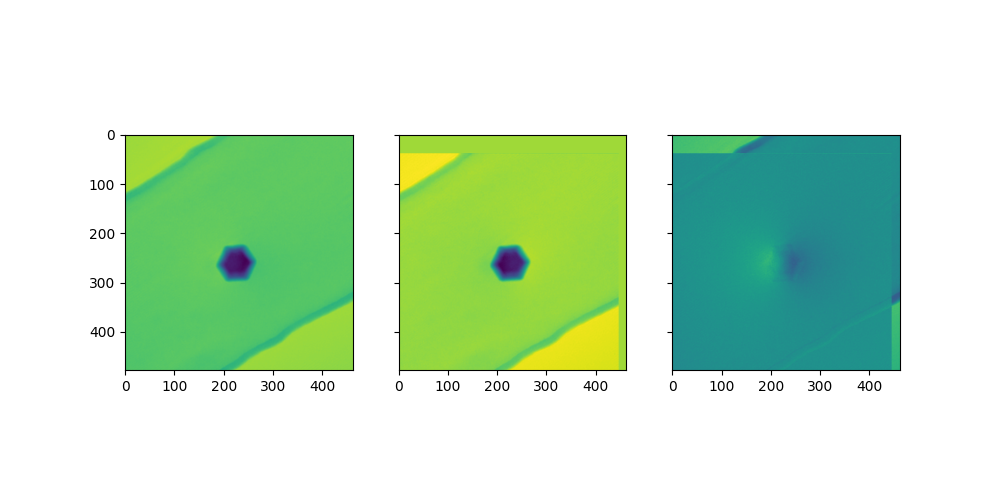

In [134]:
fig, ax = plt.subplots(ncols=3, figsize=(10, 5), sharex=True, sharey=True)
ax[0].imshow(phase_minus)
ax[1].imshow(phase_plus_shifted)
ax[2].imshow(phase_minus - phase_plus_shifted)

In [136]:
MIP_phase = (phase_minus + phase_plus_shifted) / 2
MAG_phase = (phase_minus - phase_plus_shifted) / 2

Text(0.5, 1.0, 'cos(MAG*16)')

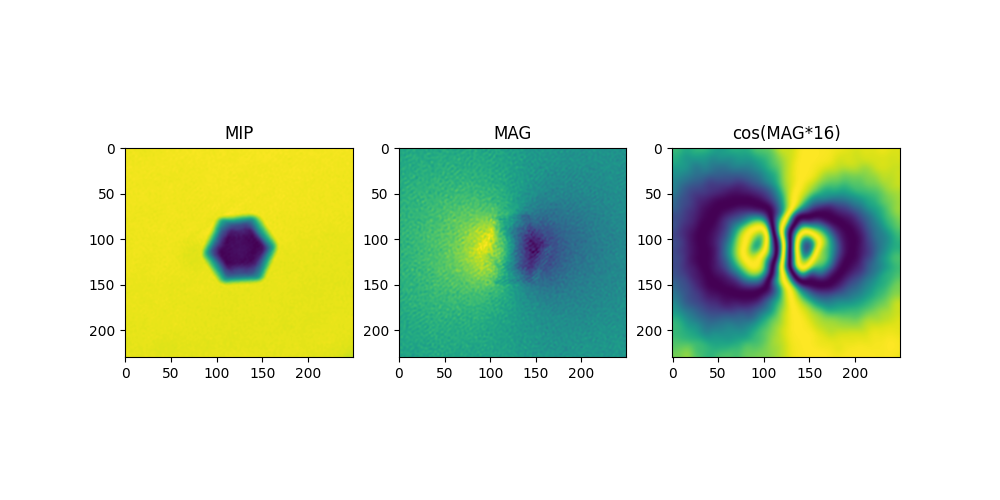

In [137]:
fig, ax = plt.subplots(ncols=3, figsize=(10, 5))
roi = np.s_[150:380, 100:350]
ax[0].imshow(MIP_phase[roi])
ax[0].set_title('MIP')

ax[1].imshow(MAG_phase[roi])
ax[1].set_title('MAG')

ax[2].imshow(np.cos(gaussian_filter(MAG_phase[roi], sigma=5)*16))
ax[2].set_title('cos(MAG*16)')

# What if data is noisy ?